## Create a new environment in bioconda (miniconda)

In [ ]:
!conda create -n 16s-nanopore -c bioconda -c conda-forge nanoplot cutadapt chopper kma emu osfclient -y
!conda activate 16s-nanopore

In [ ]:
# Sanity check using 'conda run' to point to the correct environment
!conda run -n 16s-nanopore NanoPlot --version
!conda run -n 16s-nanopore cutadapt --version
!conda run -n 16s-nanopore chopper --version
!conda run -n 16s-nanopore emu --version
!conda run -n 16s-nanopore osf -V
!conda run -n 16s-nanopore kma -v

## Renamed

In [ ]:
import os
import shutil
import pandas as pd

# 1. Paths
folder = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/16s'
csv_file = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/meta_date_16s.csv'
renamed_folder = os.path.join(folder, 'renamed')  # raw files stay untouched
os.makedirs(renamed_folder, exist_ok=True)

# 2. Read metadata (comma is the expected separator for a .csv)
df = pd.read_csv(csv_file, sep=',')
assert {'Name', 'sample_title'}.issubset(df.columns), f"Missing columns, found: {df.columns.tolist()}"

dupes = df['sample_title'][df['sample_title'].duplicated()].tolist()
if dupes:
    raise ValueError(f"Duplicate sample_title values would overwrite files: {dupes}")

log = []

# 3. Copy files under the new name, preserving the original extension
for _, row in df.iterrows():
    old_name = str(row['Name']).strip()
    sample_title = str(row['sample_title']).strip()
    old_path = os.path.join(folder, old_name)

    if not os.path.exists(old_path):
        print(f"[ERROR] File not found: {old_name}")
        continue

    if old_name.endswith('.fastq.gz'):
        ext = '.fastq.gz'
    elif old_name.endswith('.fastq'):
        ext = '.fastq'
    else:
        ext = os.path.splitext(old_name)[1]

    new_name = f"{sample_title}{ext}"
    new_path = os.path.join(renamed_folder, new_name)

    shutil.copy2(old_path, new_path)
    log.append({'old_name': old_name, 'new_name': new_name})
    print(f"[SUCCESS] Copied: {old_name} -> {new_name}")

pd.DataFrame(log).to_csv(os.path.join(renamed_folder, 'rename_manifest.csv'), index=False)
print("Done!")

## Library and directory preparation

In [ ]:
import os
import subprocess

# 1. Paths configuration (Updating based on your previous paths)
renamed_folder = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/16s/renamed'
base_out = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream'

# Define specific output folders for each step
qc_dir = os.path.join(base_out, '1_qc_raw')
trimmed_dir = os.path.join(base_out, '2_trimmed')
filtered_dir = os.path.join(base_out, '3_filtered')
emu_dir = os.path.join(base_out, '4_emu_taxa')

# Create directories if they don't exist
for directory in [qc_dir, trimmed_dir, filtered_dir, emu_dir]:
    os.makedirs(directory, exist_ok=True)

# 2. Get list of renamed files
fastq_files = [f for f in os.listdir(renamed_folder) if f.endswith('.fastq') or f.endswith('.fastq.gz')]
print(f"Found {len(fastq_files)} fastq files to process.")

## Quality control of the reads

In [ ]:
from pathlib import Path
import subprocess

env = "16s-nanopore"
threads = "4"

renamed_folder = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/16s/renamed")
qc_dir = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/1_qc_raw")
qc_dir.mkdir(parents=True, exist_ok=True)

# Removido o multiqc da instalação
subprocess.run(
    f"conda install -n {env} -c bioconda -c conda-forge nanocomp -y",
    shell=True,
    check=True
)

fastq_files = sorted(
    file for file in renamed_folder.iterdir()
    if file.name.endswith((".fastq", ".fastq.gz"))
)

print(f"Starting QC for {len(fastq_files)} samples...")

for file in fastq_files:
    sample = file.name.split(".fastq")[0]
    print(f"Running NanoPlot (with dot plots): {sample}")

    subprocess.run([
        "conda", "run", "-n", env, "NanoPlot",
        "-t", threads, "--fastq", str(file),
        "-o", str(qc_dir / sample),
        "--plots", "dot"
    ], check=True)

nanocomp_out = qc_dir / "NanoComp_Report"
nanocomp_out.mkdir(exist_ok=True)

print("Generating NanoComp report...")
subprocess.run([
    "conda", "run", "-n", env, "NanoComp", "-t", threads,
    "--fastq", *map(str, fastq_files),
    "--names", *(file.name.split(".fastq")[0] for file in fastq_files),
    "-o", str(nanocomp_out)
], check=True)

print("\nQuality control completed!")
print(f"NanoComp report: {nanocomp_out}")

For decision trimmer, use the LengthvsQualityScatterPlot_kde, which is a tool that generates a scatter plot of read lengths versus quality scores. This can help identify any issues with the sequencing data, such as low-quality reads or unexpected length distributions.

## Filter reads by length with chopper

Trim the reads to a specific length range using chopper. This step is important to ensure that only reads of the desired length are retained for downstream analysis. The command will filter the reads based on the specified minimum and maximum length thresholds.

In [5]:
# 5. Run Chopper for quality and length filtering
import os
import subprocess

renamed_folder = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/16s/renamed")
filtered_dir = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/3_filtered")
filtered_dir.mkdir(parents=True, exist_ok=True)

fastq_files = [f for f in os.listdir(renamed_folder) if f.endswith('.fastq') or f.endswith('.fastq.gz')]

failed_samples = []

for file in fastq_files:
    sample_name = file.split('.fastq')[0]
    input_path = os.path.join(renamed_folder, file)
    output_path = os.path.join(filtered_dir, f"{sample_name}_filtered.fastq")
    
    bash_cmd = (
        f"conda run -n 16s-nanopore bash -c "
        f"\"zcat -f '{input_path}' | "
        f"chopper "
        f"-q 15 "
        f"--minlength 1000 " #Is the minimum length of the reads to keep. Reads shorter than this will be discarded.
        f"--maxlength 1700 " #Is the maximum length of the reads to keep. Reads longer than this will be discarded.
        f"> '{output_path}'\""
    )
    
    print(f"Filtering {sample_name}...")
    
    try:
        # check=True Makes subprocess.run raise an exception if the command fails
        subprocess.run(bash_cmd, shell=True, check=True)
    except subprocess.CalledProcessError as e:
        print(f"\n[ERROR] {sample_name}!")
        print("Skipping to the next sample...\n")
        failed_samples.append(sample_name)
        
        if os.path.exists(output_path):
            os.remove(output_path)

print("\n--- Filtered end ---")
if failed_samples:
    print(f"Failed samples: {failed_samples}")
else:
    print("All samples were processed successfully!")

Filtering CTL-2...


Kept 670 reads out of 1199 reads


Filtering MOT-2...


Kept 3416 reads out of 5059 reads


Filtering FAT-3...


...

Kept 2247 reads out of 3511 reads


Filtering MOT-3...


Kept 3080 reads out of 4940 reads


Filtering CTL-1...

--- Filtered end ---
All samples were processed successfully!


Kept 3030 reads out of 4690 reads


## Count Reads: Before, after and classification

In [17]:
import os
import subprocess
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Define the input and output folders
renamed_folder = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/16s/renamed")
filtered_dir = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/3_filtered")

# 2. Get the list of original fastq files
fastq_files = sorted([f for f in os.listdir(renamed_folder) if f.endswith('.fastq') or f.endswith('.fastq.gz')])

print("\n--- Read Count Summary ---")

def get_read_count(filepath):
    """Returns the number of reads in a fastq or fastq.gz file."""
    if not os.path.exists(filepath):
        return 0
    try:
        cmd = f"zcat -f '{filepath}' | wc -l"
        result = subprocess.check_output(cmd, shell=True, text=True)
        return int(result.strip()) // 4
    except Exception:
        return 0

data_list = []

# 3. Loop through the files to count reads before and after
for file in fastq_files:
    sample_name = file.split('.fastq')[0]
    
    input_path = os.path.join(renamed_folder, file) 
    output_path = os.path.join(filtered_dir, f"{sample_name}_filtered.fastq")
    
    reads_before = get_read_count(input_path)
    reads_after = get_read_count(output_path)
    
    if reads_before > 0:
        retention = (reads_after / reads_before) * 100
    else:
        retention = 0.0
        
    print(f"Sample: {sample_name}")
    print(f"  Before: {reads_before:,} reads")
    print(f"  After:  {reads_after:,} reads ({retention:.2f}% retained)")
    
    data_list.append({
        "Sample": sample_name,
        "Before Filtering": reads_before,
        "After Filtering": reads_after
    })

# 4. Create DataFrame and Plot
df = pd.DataFrame(data_list).set_index("Sample")

ax = df.plot(
    kind='bar', 
    figsize=(14, 7), 
    color=['#1f77b4', "#cf1c04"], 
    width=0.7,
    edgecolor='black',
    linewidth=0.8
)

plt.title("Reads Before and After Filtering", fontsize=16, pad=15)
plt.ylabel("Number of Reads", fontsize=12)
plt.xlabel("Samples", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Add exact read counts above each bar
for container in ax.containers:
    ax.bar_label(
        container, 
        fmt='{:,.0f}', 
        padding=3.2, 
        fontsize=8, 
        fontweight='bold', 
        color='#333333',
        rotation=0 # Rotacionado para evitar sobreposição se os números forem grandes
    )

plt.legend(loc='upper right', framealpha=0.9)
plt.tight_layout()

# 6. Save the image
output_image = "/home/marcos/Imagens/colab/dados_de_qualidade_16s/Reads_Before_vs_After_Filtering.png"
plt.savefig(output_image, dpi=300)
print(f"\nImage saved to: {output_image}")


--- Read Count Summary ---
Sample: CTL-1
  Before: 4,690 reads
  After:  3,030 reads (64.61% retained)
Sample: CTL-2
  Before: 1,199 reads
  After:  670 reads (55.88% retained)
Sample: CTL-3
  Before: 1,608 reads
  After:  1,029 reads (63.99% retained)
Sample: DES-1
  Before: 3,036 reads
  After:  1,952 reads (64.30% retained)
Sample: DES-2
  Before: 1,997 reads
  After:  1,293 reads (64.75% retained)
Sample: DES-3
  Before: 7,357 reads
  After:  4,413 reads (59.98% retained)
Sample: FAT-1
  Before: 3,457 reads
  After:  2,191 reads (63.38% retained)
Sample: FAT-2
  Before: 3,184 reads
  After:  1,944 reads (61.06% retained)
Sample: FAT-3
  Before: 2,988 reads
  After:  1,822 reads (60.98% retained)
Sample: MOT-1
  Before: 3,511 reads
  After:  2,247 reads (64.00% retained)
Sample: MOT-2
  Before: 5,059 reads
  After:  3,416 reads (67.52% retained)
Sample: MOT-3
  Before: 4,940 reads
  After:  3,080 reads (62.35% retained)

Image saved to: /home/marcos/Imagens/colab/dados_de_qualidade

In [7]:
import os
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Define paths
renamed_folder = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/16s/renamed")
filtered_dir = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/3_filtered")

def get_read_count(filepath):
    """Counts reads in a fastq or fastq.gz file."""
    if not os.path.exists(filepath):
        return 0
    try:
        cmd = f"zcat -f '{filepath}' | wc -l"
        result = subprocess.check_output(cmd, shell=True, text=True)
        return int(result.strip()) // 4
    except Exception:
        return 0

# 2. Count raw and filtered reads from FASTQ files
print("Counting raw and filtered reads...")
# ADDED sorted() HERE TO ORGANIZE THE SAMPLES
fastq_files = sorted([f for f in os.listdir(renamed_folder) if f.endswith('.fastq') or f.endswith('.fastq.gz')])
stats_list = []

for file in fastq_files:
    sample_name = file.replace('.fastq.gz', '').replace('.fastq', '')
    
    raw_path = os.path.join(renamed_folder, file) 
    filtered_path = os.path.join(filtered_dir, f"{sample_name}_filtered.fastq")
    
    stats_list.append({
        "Sample": sample_name,
        "1. Before QC": get_read_count(raw_path),
        "2. After QC": get_read_count(filtered_path)
    })

df_fastq = pd.DataFrame(stats_list).set_index("Sample")

# 3. Generate the plot
print("Generating chart...")

ax = df_fastq.plot(
    kind='bar', 
    stacked=False, 
    figsize=(12, 6), 
    color=['#1f77b4', '#ff7f0e'], 
    width=0.75,
    edgecolor='black',
    linewidth=0.5
)

plt.title("Read Tracking: Before vs After QC", fontsize=15, pad=15)
plt.ylabel("Number of Reads", fontsize=12)
plt.xlabel("Samples", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title="Pipeline Stage", fontsize=11)
plt.tight_layout()

# Save and display
output_image = "/home/marcos/Imagens/colab/dados_de_qualidade_16s/read_counts_qc_only_16s.png"
plt.savefig(output_image, dpi=300)
print(f"\n[SUCCESS] Chart saved to: {output_image}")

plt.show()

Counting raw and filtered reads...
Generating chart...

[SUCCESS] Chart saved to: /home/marcos/Imagens/colab/dados_de_qualidade_16s/read_counts_qc_only_16s.png


/tmp/ipykernel_46364/4244461028.py:68: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Classify the reads using the SILVA database

1. Download and extract the SILVA database for taxonomic classification.

Download the SILVA database (NR99 version) and extract it to the specified directory. This database will be used for taxonomic classification of the 16S rRNA gene sequences.

In [ ]:
%%bash
BASE_DIR="/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream"
DB_DIR="$BASE_DIR/silva_database"

mkdir -p $DB_DIR

# Download the SILVA database (NR99 version 138.2)
echo "Initiating download of the SILVA database"

wget -nc -O $DB_DIR/SILVA_138.2_SSURef_NR99_tax_silva.fasta.gz "https://www.arb-silva.de/fileadmin/silva_databases/release_138_2/Exports/SILVA_138.2_SSURef_NR99_tax_silva.fasta.gz"
gunzip -f $DB_DIR/SILVA_138.2_SSURef_NR99_tax_silva.fasta.gz

echo "Download and extraction completed successfully!"

2. Defining the reference database 

In [ ]:
%%bash
BASE_DIR="/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream"
DB_DIR="$BASE_DIR/silva_database"
KMA_DIR="$BASE_DIR/kma_silva_db"
mkdir -p $KMA_DIR

ORIGINAL_FASTA="$DB_DIR/SILVA_138.2_SSURef_NR99_tax_silva.fasta"
BACTERIA_FASTA="$DB_DIR/SILVA_16S_Bacteria.fasta"

echo "Initiating filtration of Eukaryotes and Archaea..."
awk '/^>/ {p = ($0 ~ /Bacteria;/)} p' $ORIGINAL_FASTA > $BACTERIA_FASTA
echo "Filtration completed! File BACTERIA_FASTA created."

3. Taxonomic extraction

In [ ]:
%%bash
BASE_DIR="/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream"
DB_DIR="$BASE_DIR/silva_database"
BACTERIA_FASTA="$DB_DIR/SILVA_16S_Bacteria.fasta"

echo "Extracting taxonomy for CSV..."
grep "^>" $BACTERIA_FASTA > $DB_DIR/headers_silva.txt
awk -F' ' '{print $1 "," substr($0, index($0,$2))}' $DB_DIR/headers_silva.txt > $DB_DIR/split_headers.csv
sed -i 's/;/,/g' $DB_DIR/split_headers.csv 
echo "id,Kingdom,Phylum,Class,Order,Family,Genus,Species" > $DB_DIR/silva_taxonomy.csv
sed 's/^>//' $DB_DIR/split_headers.csv >> $DB_DIR/silva_taxonomy.csv
echo "Taxonomy extracted successfully!"

4. Clear header FASTA

In [ ]:
%%bash
BASE_DIR="/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream"
DB_DIR="$BASE_DIR/silva_database"
BACTERIA_FASTA="$DB_DIR/SILVA_16S_Bacteria.fasta"

echo "Cleaning the FASTA file..."
sed -i 's/ .*//' $BACTERIA_FASTA
echo "Cleaned FASTA!"

5. Indexing in KMA

In [ ]:
%%bash
eval "$(conda shell.bash hook)"
conda activate 16s-nanopore
BASE_DIR="/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream"
DB_DIR="$BASE_DIR/silva_database"
KMA_DIR="$BASE_DIR/kma_silva_db"
BACTERIA_FASTA="$DB_DIR/SILVA_16S_Bacteria.fasta"

echo "Initiating KMA indexing of the SILVA database"
kma index -i $BACTERIA_FASTA -o $KMA_DIR/silva_db
echo "KMA indexing of the SILVA database completed successfully!"

6. KMA classification (SILVA)

In [ ]:
#3.kma classification
import subprocess
from pathlib import Path

input_dir = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/3_filtered")
kma_out = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/silva")
kma_out.mkdir(parents=True, exist_ok=True)

# Replace with your actual KMA database path
kma_db = "/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/kma_silva_db/silva_db"

fastq_files = [f for f in input_dir.iterdir() if f.name.endswith('.fastq')]

print(f"Starting KMA classification for {len(fastq_files)} samples...")

for file in fastq_files:
    sample_name = file.name.split('_filtered')[0]
    out_prefix = kma_out / sample_name
    
    cmd = [
        "conda", "run", "-n", "16s-nanopore",
        "kma",
        "-i", str(file),
        "-o", str(out_prefix),
        "-t_db", kma_db,
        "-bcNano",         # Optimizes for Nanopore errors
        "-ont", # Optimizes for ONT reads
        "-ID", "95.0",   # Reliability: Minimum 99% identity, indentification for species-level classification; but you can adjust for 97% indentification for genus-level classification
        "-bc", "0.7",    # Reliability: 99% statistical confidence
        "-t", "4"
    ]
    
    print(f"Running KMA for {sample_name}...")
    
    try:
        subprocess.run(cmd, check=True)
    except subprocess.CalledProcessError:
        print(f"[ERROR] Failed to classify {sample_name}")

print("\nKMA classification finished.")

Starting KMA classification for 12 samples...
Running KMA for FAT-1...


6. KMA classification (NCBI)

In [1]:
#3.kma classification
import subprocess
from pathlib import Path

input_dir = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/3_filtered")
kma_out = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/ncbi")
kma_out.mkdir(parents=True, exist_ok=True)

# Replace with your actual KMA database path
kma_db = "/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/kma_ncbi_db/ncbi_db"

fastq_files = [f for f in input_dir.iterdir() if f.name.endswith('.fastq')]

print(f"Starting KMA classification for {len(fastq_files)} samples...")

for file in fastq_files:
    sample_name = file.name.split('_filtered')[0]
    out_prefix = kma_out / sample_name
    
    cmd = [
        "conda", "run", "-n", "16s-nanopore",
        "kma",
        "-i", str(file),
        "-o", str(out_prefix),
        "-t_db", kma_db,
        "-bcNano",         # Optimizes for Nanopore errors
        "-ont", # Optimizes for ONT reads
        "-ID", "95.0",   # Reliability: Minimum 99% identity, indentification for species-level classification; but you can adjust for 97% indentification for genus-level classification
        "-bc", "0.7",    # Reliability: 99% statistical confidence
        "-t", "4"
    ]
    
    print(f"Running KMA for {sample_name}...")
    
    try:
        subprocess.run(cmd, check=True)
    except subprocess.CalledProcessError:
        print(f"[ERROR] Failed to classify {sample_name}")

print("\nKMA classification finished.")

Starting KMA classification for 12 samples...
Running KMA for FAT-1...


# Reading inputfile: 	/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/3_filtered/FAT-1_filtered.fastq
# Phred scale:	33
# Running KMA.
#
# Total time used for DB loading: 0.32 s.
#
# Finding k-mer ankers
#
# Total number of query fragment after trimming:	2727
#
# Query converted
#
# Query ankered
#
# KMA mapping done
#
# Sort, output and select KMA alignments.
# Total time for sorting and outputting KMA alignment	0.01 s.
#
# Doing local assemblies of found templates, and output results
# Total time used for local assembly: 0.52 s.
#
# Closing files


Running KMA for DES-1...


# Running KMA.
# Reading inputfile: 	/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/3_filtered/DES-1_filtered.fastq
# Phred scale:	33
#
# Total time used for DB loading: 0.08 s.
#
# Finding k-mer ankers
#
# Total number of query fragment after trimming:	2369
#
# Query converted
#
# Query ankered
#
# KMA mapping done
#
# Sort, output and select KMA alignments.
# Total time for sorting and outputting KMA alignment	0.00 s.
#
# Doing local assemblies of found templates, and output results
# Total time used for local assembly: 0.46 s.
#
# Closing files


Running KMA for FAT-3...


...

# Running KMA.
# Reading inputfile: 	/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/3_filtered/MOT-2_filtered.fastq
# Phred scale:	33
#
# Total time used for DB loading: 0.06 s.
#
# Finding k-mer ankers
#
# Total number of query fragment after trimming:	4101
#
# Query converted
#
# Query ankered
#
# KMA mapping done
#
# Sort, output and select KMA alignments.
# Total time for sorting and outputting KMA alignment	0.01 s.
#
# Doing local assemblies of found templates, and output results
# Total time used for local assembly: 0.83 s.
#
# Closing files


Running KMA for CTL-3...


# Running KMA.
# Reading inputfile: 	/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/3_filtered/CTL-3_filtered.fastq
# Phred scale:	33
#
# Total time used for DB loading: 0.06 s.
#
# Finding k-mer ankers
#
# Total number of query fragment after trimming:	1238
#
# Query converted
#
# Query ankered
#
# KMA mapping done
#
# Sort, output and select KMA alignments.
# Total time for sorting and outputting KMA alignment	0.00 s.
#
# Doing local assemblies of found templates, and output results
# Total time used for local assembly: 0.35 s.
#
# Closing files


Running KMA for CTL-1...

KMA classification finished.


# Running KMA.
# Reading inputfile: 	/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/3_filtered/CTL-1_filtered.fastq
# Phred scale:	33
#
# Total time used for DB loading: 0.06 s.
#
# Finding k-mer ankers
#
# Total number of query fragment after trimming:	3633
#
# Query converted
#
# Query ankered
#
# KMA mapping done
#
# Sort, output and select KMA alignments.
# Total time for sorting and outputting KMA alignment	0.01 s.
#
# Doing local assemblies of found templates, and output results
# Total time used for local assembly: 0.71 s.
#
# Closing files


Count reads before and after the classification step to assess the impact of the classification process on the dataset.

In [2]:
import os
import subprocess
import pandas as pd
import matplotlib
matplotlib.use('Agg') 
import matplotlib.pyplot as plt
from pathlib import Path

# Directories
kma_dir = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/ncbi")
fastq_dir = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/3_filtered")
fastq_suffix = "_filtered.fastq" 

def count_reads(filepath):
    """Counts the number of reads (lines / 4) for both .gz and plain text files."""
    if not os.path.exists(filepath):
        return 0
    try:
        if str(filepath).endswith('.gz'):
            cmd = f"zcat -f '{filepath}' | wc -l"
        else:
            cmd = f"wc -l < '{filepath}'"
            
        result = subprocess.check_output(cmd, shell=True, text=True)
        return int(result.strip()) // 4
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return 0

print("\nCounting reads (Classified vs Total)...\n")

kma_files = sorted([f for f in os.listdir(kma_dir) if f.endswith('.frag.gz')])
data_list = []

if not kma_files:
    print("No KMA files found.")
else:
    for file in kma_files:
        sample_name = file.replace('.frag.gz', '')
        kma_path = kma_dir / file
        fastq_path = fastq_dir / f"{sample_name}{fastq_suffix}"
        
        classified = count_reads(kma_path)
        total = count_reads(fastq_path)
        
        if total > 0:
            unclassified = max(0, total - classified)
            perc = (classified / total) * 100
        else:
            unclassified = 0
            perc = 0.0
            print(f"  [WARNING] FASTQ file not found or empty: {fastq_path}")

        data_list.append({
            "Sample": sample_name, 
            "Classified": classified, 
            "Unclassified": unclassified,
            "Total": total,
            "Percentage": perc
        })
        print(f"  {sample_name}: {classified:,} classified / {total:,} total ({perc:.1f}%)")

    df = pd.DataFrame(data_list).set_index("Sample")

    print("-" * 50)
    print(f"  TOTAL CLASSIFIED: {df['Classified'].sum():,}")
    print(f"  TOTAL OVERALL (FILTERED): {df['Total'].sum():,}")
    print("-" * 50)

    # Stacked Bar Chart Plotting
    ax = df[['Classified', 'Unclassified']].plot(
        kind='bar', 
        stacked=True,
        figsize=(12, 6), 
        color=['#9467bd', 'lightgray'], 
        width=0.7,
        edgecolor='black',
        linewidth=0.5
    )

    plt.title("Classified vs Unclassified Reads (16S)", fontsize=15, pad=15)
    plt.ylabel("Number of Reads", fontsize=12)
    plt.xlabel("Samples", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    plt.ticklabel_format(style='plain', axis='y') 
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Percentage Annotations
    for i, (idx, row) in enumerate(df.iterrows()):
        total_reads = row['Total']
        perc = row['Percentage']
        
        if total_reads > 0:
            y_pos = total_reads + (df['Total'].max() * 0.02)
            ax.text(i, y_pos, f"{perc:.1f}%", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

    plt.legend(["Classified (KMA)", "Unclassified"], loc='upper right', framealpha=0.9)
    plt.tight_layout()

    # Save Output
    output_image = "/home/marcos/Imagens/colab/dados_de_qualidade_16s/Reads_classified_vs_unclassified_16s.png"
    plt.savefig(output_image, dpi=300)
    print(f"Image saved to: {output_image}")


Counting reads (Classified vs Total)...

  CTL-1: 919 classified / 3,633 total (25.3%)
  CTL-2: 200 classified / 821 total (24.4%)
  CTL-3: 310 classified / 1,238 total (25.0%)
  DES-1: 590 classified / 2,369 total (24.9%)
  DES-2: 384 classified / 1,558 total (24.6%)
  DES-3: 1,320 classified / 5,357 total (24.6%)
  FAT-1: 684 classified / 2,727 total (25.1%)
  FAT-2: 596 classified / 2,393 total (24.9%)
  FAT-3: 554 classified / 2,215 total (25.0%)
  MOT-1: 686 classified / 2,793 total (24.6%)
  MOT-2: 1,021 classified / 4,101 total (24.9%)
  MOT-3: 946 classified / 3,792 total (24.9%)
--------------------------------------------------
  TOTAL CLASSIFIED: 8,210
  TOTAL OVERALL (FILTERED): 32,997
--------------------------------------------------
Image saved to: /home/marcos/Imagens/colab/dados_de_qualidade_16s/Reads_classified_vs_unclassified_16s.png


# Merge KMA results

In [4]:
import pandas as pd
from pathlib import Path

# 1. Define the directory where KMA saved the results
kma_dir = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/ncbi")

# 2. Find all KMA result files (.res)
res_files = list(kma_dir.glob("*.res"))
print(f"Found {len(res_files)} KMA result files. Merging them now...")

df_list = []

# 3. Read each file and extract the taxonomy and actual READ COUNTS
for file in res_files:
    sample_name = file.stem  # Gets the sample name without the .res extension
    
    # Read the tab-separated KMA output
    df = pd.read_csv(file, sep='\t')
    
    # Automatically detect the correct column for read counts
    if 'readCount' in df.columns:
        count_col = 'readCount'
    elif 'Expected' in df.columns:
        count_col = 'Expected'
    else:
        print(f"Warning: Could not find 'readCount' or 'Expected' in {file.name}")
        count_col = df.columns[2] # Fallback to the 3rd column
        
    # Keep only the Taxonomy Name (#Template) and the Read Count
    df = df[['#Template', count_col]].copy()
    df = df.rename(columns={count_col: sample_name})
    df.set_index('#Template', inplace=True)
    
    # KMA 'Expected' can have decimals (due to multi-mapping), so we round it to integers
    df = df.round(0).astype(int)
    
    df_list.append(df)

# 4. Combine all samples into a single matrix and fill missing values with 0
otu_matrix = pd.concat(df_list, axis=1).fillna(0).astype(int)

# 5. Save the final matrix
output_file = kma_dir / "otu_abundance_matrix.csv"
otu_matrix.to_csv(output_file)

print(f"\nMatrix successfully saved to:\n{output_file}")

Found 12 KMA result files. Merging them now...

Matrix successfully saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/ncbi/otu_abundance_matrix.csv


1. kma classification

In [6]:
import pandas as pd
from pathlib import Path

# =========================================================
# 1. Paths
# =========================================================

matrix_dir = Path(
    "/home/marcos/colaboracao/paulo_de_melo/"
    "RICHARDT-GAMA-LANDGRAF_results/"
    "RICHARDT-GAMA-LANDGRAF_results/"
    "downstream/4_kma_taxa/ncbi"
)

raw_matrix_path = matrix_dir / "otu_abundance_matrix.csv"
clean_matrix_path = matrix_dir / "otu_abundance_matrix_CLEAN.csv"

tax_db_path = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/ncbi_database/taxonomy.tsv")

# =========================================================
# 2. Load KMA abundance matrix
# =========================================================

print("Loading KMA abundance matrix...")

df = pd.read_csv(raw_matrix_path)

# Extract tax_id from #Template
df["tax_id"] = (
    df["#Template"]
    .astype(str)
    .str.split(":")
    .str[0]
)

# Preserve original KMA template
df = df.rename(columns={"#Template": "raw_taxonomy"})

print(f"KMA entries: {len(df)}")
print(f"Unique tax IDs: {df['tax_id'].nunique()}")

# =========================================================
# 3. Load NCBI taxonomy manually
#    This handles malformed lines safely
# =========================================================

print("\nLoading NCBI taxonomy database...")

expected_fields = 8
taxonomy_rows = []
bad_lines = []

with open(tax_db_path, "r", encoding="utf-8", errors="replace") as f:

    for line_number, line in enumerate(f, start=1):

        line = line.rstrip("\n\r")

        fields = line.split("\t")

        if len(fields) == expected_fields:

            taxonomy_rows.append(fields)

        elif len(fields) > expected_fields:

            # Keep first 7 taxonomy fields
            # Merge everything else into species
            fixed_fields = fields[:7] + [",".join(fields[7:])]

            taxonomy_rows.append(fixed_fields)

            bad_lines.append(
                (line_number, len(fields), line)
            )

        else:

            bad_lines.append(
                (line_number, len(fields), line)
            )

# =========================================================
# 4. Create taxonomy dataframe
# =========================================================

tax_columns = [
    "tax_id",
    "superkingdom",
    "phylum",
    "class",
    "order",
    "family",
    "genus",
    "species"
]

tax_db = pd.DataFrame(
    taxonomy_rows,
    columns=tax_columns
)

# Ensure tax_id is string
tax_db["tax_id"] = tax_db["tax_id"].astype(str)

print(f"NCBI taxonomy entries: {len(tax_db)}")
print(f"Unique NCBI tax IDs: {tax_db['tax_id'].nunique()}")

# =========================================================
# 5. Report malformed lines
# =========================================================

print("\nMalformed lines detected:")

if bad_lines:

    for line_number, n_fields, line in bad_lines[:20]:
        print(
            f"Line {line_number}: "
            f"{n_fields} fields"
        )
        print(line)

    if len(bad_lines) > 20:
        print(
            f"... and {len(bad_lines) - 20} additional lines."
        )

else:
    print("None.")

# =========================================================
# 6. Check tax_id matching
# =========================================================

matched = df["tax_id"].isin(tax_db["tax_id"])

print("\nTaxonomy matching:")
print(f"Matched: {matched.sum()}")
print(f"Not matched: {(~matched).sum()}")
print(f"Match rate: {matched.mean() * 100:.2f}%")

# Show unmatched IDs
if (~matched).sum() > 0:

    print("\nFirst unmatched tax IDs:")

    print(
        df.loc[~matched, "tax_id"]
        .drop_duplicates()
        .head(20)
        .to_string(index=False)
    )

# =========================================================
# 7. Merge abundance + taxonomy
# =========================================================

df_merged = pd.merge(
    df,
    tax_db,
    on="tax_id",
    how="left"
)

# =========================================================
# 8. Select final columns
# =========================================================

sample_cols = [
    col for col in df.columns
    if col not in ["tax_id", "raw_taxonomy"]
]

final_cols = tax_columns + sample_cols

df_clean = df_merged[final_cols]

# =========================================================
# 9. Save
# =========================================================

df_clean.to_csv(
    clean_matrix_path,
    index=False
)

print("\n========================================")
print("SUCCESS")
print("========================================")
print(f"Clean matrix saved to:")
print(clean_matrix_path)

print(f"\nFinal dimensions: {df_clean.shape}")

Loading KMA abundance matrix...
KMA entries: 73
Unique tax IDs: 60

Loading NCBI taxonomy database...
NCBI taxonomy entries: 17557
Unique NCBI tax IDs: 17557

Malformed lines detected:
Line 1: 12 fields
tax_id	species	genus	family	order	class	phylum	clade	superkingdom	subspecies	species subgroup	species group
Line 2: 12 fields
2594042	Candidatus Prometheoarchaeum syntrophicum	Candidatus Prometheoarchaeum				Candidatus Lokiarchaeota	Asgard group	Archaea			
Line 3: 12 fields
1920749	Candidatus Mancarchaeum acidiphilum	Candidatus Mancarchaeum				Candidatus Micrarchaeota	DPANN group	Archaea			
Line 4: 12 fields
1291540	Candidatus Methanomethylophilus alvus	Candidatus Methanomethylophilus	Candidatus Methanomethylophilaceae	Methanomassiliicoccales	Thermoplasmata	Euryarchaeota	Diaforarchaea group	Archaea			
Line 5: 12 fields
1577791	Candidatus Methanoplasma termitum	Candidatus Methanoplasma	Methanomassiliicoccaceae	Methanomassiliicoccales	Thermoplasmata	Euryarchaeota	Diaforarchaea group	Archa

## Rarefaction curves

Found 12 .frag files in /home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/ncbi

CTL-1: 3677 aligned reads, 50 valid genera.
CTL-2: 802 aligned reads, 28 valid genera.
CTL-3: 1241 aligned reads, 45 valid genera.
DES-1: 2363 aligned reads, 40 valid genera.
DES-2: 1537 aligned reads, 41 valid genera.
DES-3: 5283 aligned reads, 78 valid genera.
FAT-1: 2737 aligned reads, 35 valid genera.
FAT-2: 2385 aligned reads, 66 valid genera.
FAT-3: 2218 aligned reads, 51 valid genera.
MOT-1: 2746 aligned reads, 75 valid genera.
MOT-2: 4085 aligned reads, 71 valid genera.
MOT-3: 3784 aligned reads, 59 valid genera.

Plot saved to: /home/marcos/Imagens/colab/dados_de_qualidade_16s/curva_rarefacao.png


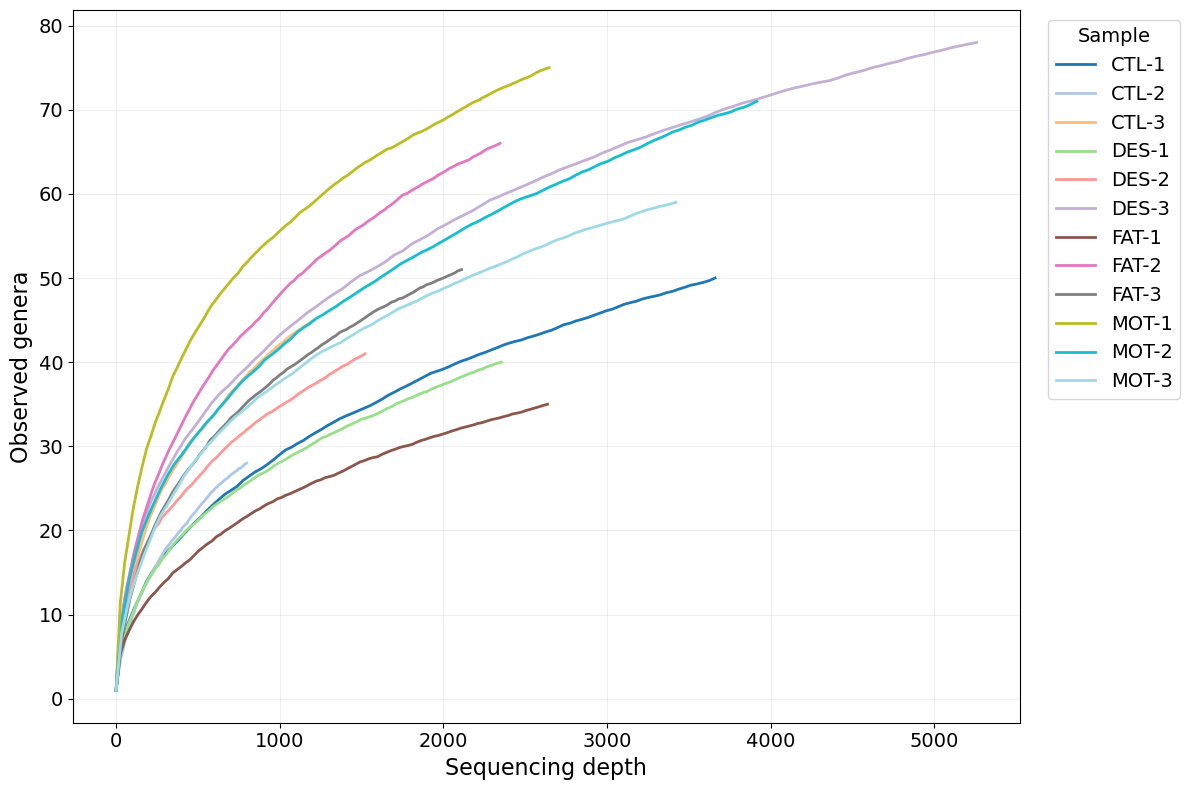

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================

FRAG_DIR = Path(
    "/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/"
    "RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/ncbi"
)
FRAG_SUFFIX = ".frag.gz"  # stripped from the filename to get the sample ID

TAXONOMY_PATH = (
    "/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/"
    "RICHARDT-GAMA-LANDGRAF_results/downstream/ncbi_database/taxonomy.tsv"
)

EXCLUDED_GENERA = ["Unclassified"]  # dropped before computing richness

# Optional: path to an already-filtered table (e.g. your final TaxCount_Genus
# matrix) whose sample columns or genus index define which genera are valid
# after your prevalence/contamination filters. None = use every genus found
# in the .frag files (minus EXCLUDED_GENERA).
VALID_GENERA_PATH = None
VALID_GENERA_COLUMN = "genus"  # only used if VALID_GENERA_PATH is set

OUTPUT_PLOT_PATH = "/home/marcos/Imagens/colab/dados_de_qualidade_16s/curva_rarefacao.png"

N_DEPTHS = 100    # number of sequencing depths tested per sample
N_REPEATS = 100   # subsampling repeats per depth
SEED = 42

XLIM = None  # e.g. (0, 1500) to zoom into the start of the curve; None = auto

# .frag files have 7 tab-separated fields (read, num_templates, score, start,
# end, template, read_id). index_col=False keeps pandas from silently using
# the first column as an index if a mismatch ever creeps back in.
FRAG_COLUMNS = ["read", "num_templates", "score", "start", "end", "template", "read_id"]


# ============================================================
# FUNCTIONS
# ============================================================

def build_taxid_to_genus(taxonomy_path):
    """Map tax_id -> genus. Taxids missing or unmapped fall back to 'Unclassified'."""
    tax_df = pd.read_csv(taxonomy_path, sep="\t", dtype={"tax_id": str})
    return dict(zip(tax_df["tax_id"], tax_df["genus"]))


def load_valid_genera(path, genus_column):
    """Load a set of valid genera from a pre-filtered table, if given."""
    if path is None:
        return None
    table = pd.read_csv(path, sep=None, engine="python")
    if genus_column in table.columns:
        return set(table[genus_column].dropna().unique())
    # table is already "genus x sample", with genus as the index
    table = pd.read_csv(path, sep=None, engine="python", index_col=0)
    return set(table.index)


def load_genus_counts(frag_path, taxid_to_genus):
    """Read one .frag(.gz) file and count reads per genus."""
    df = pd.read_csv(
        frag_path, sep="\t", header=None,
        names=FRAG_COLUMNS, compression="infer", index_col=False,
    )
    taxid = df["template"].astype(str).str.split(":").str[0]
    genus = taxid.map(taxid_to_genus).fillna("Unclassified")
    return genus.value_counts()


def rarefaction_curve(genus_counts, n_depths, n_repeats, rng):
    """Mean observed genus richness at increasing sequencing depths.

    Standard trick: for each repeat, shuffle all reads once and take the
    cumulative count of distinct genera seen so far. A random permutation's
    first k reads are distributed exactly like a random sample of size k
    without replacement, so this gives the same result as resampling at
    every depth separately — just in one pass instead of n_depths passes.
    """
    reads = np.repeat(genus_counts.index.to_numpy(), genus_counts.to_numpy())
    n = len(reads)
    depths = np.unique(np.linspace(1, n, min(n_depths, n), dtype=int))

    richness_sum = np.zeros(len(depths))
    for _ in range(n_repeats):
        shuffled = rng.permutation(reads)
        _, first_seen_at = np.unique(shuffled, return_index=True)
        seen = np.zeros(n, dtype=bool)
        seen[first_seen_at] = True
        richness_sum += np.cumsum(seen)[depths - 1]

    return depths, richness_sum / n_repeats


def plot_curves(results, output_path, xlim=None):
    """Plot rarefaction curves for all samples and save to disk."""
    fig, ax = plt.subplots(figsize=(12, 8))
    colors = plt.cm.tab20(np.linspace(0, 1, len(results)))

    for color, (sample, (depths, richness)) in zip(colors, results.items()):
        ax.plot(depths, richness, lw=2, color=color, label=sample)

    ax.set_xlabel("Sequencing depth", fontsize=16)
    ax.set_ylabel("Observed genera", fontsize=16)
    ax.tick_params(axis="both", labelsize=14)
    ax.grid(alpha=0.2)
    ax.legend(title="Sample", bbox_to_anchor=(1.02, 1), loc="upper left",
              fontsize=14, title_fontsize=14)

    if xlim is not None:
        ax.set_xlim(*xlim)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"\nPlot saved to: {output_path}")
    plt.show()


# ============================================================
# MAIN
# ============================================================

if __name__ == "__main__":
    rng = np.random.default_rng(SEED)

    taxid_to_genus = build_taxid_to_genus(TAXONOMY_PATH)
    valid_genera = load_valid_genera(VALID_GENERA_PATH, VALID_GENERA_COLUMN)

    frag_files = sorted(FRAG_DIR.glob(f"*{FRAG_SUFFIX}"))
    print(f"Found {len(frag_files)} .frag files in {FRAG_DIR}\n")

    results = {}
    for frag_file in frag_files:
        sample_id = frag_file.name.replace(FRAG_SUFFIX, "")

        genus_counts = load_genus_counts(frag_file, taxid_to_genus)
        n_reads = genus_counts.sum()

        genus_counts = genus_counts.drop(
            index=[g for g in EXCLUDED_GENERA if g in genus_counts.index]
        )
        if valid_genera is not None:
            genus_counts = genus_counts[genus_counts.index.isin(valid_genera)]

        if genus_counts.empty:
            print(f"{sample_id}: no valid genera after filtering — skipping.")
            continue

        depths, richness = rarefaction_curve(genus_counts, N_DEPTHS, N_REPEATS, rng)
        results[sample_id] = (depths, richness)
        print(f"{sample_id}: {n_reads} aligned reads, {len(genus_counts)} valid genera.")

    plot_curves(results, OUTPUT_PLOT_PATH, XLIM)

## Reads annotation

In [7]:
import pandas as pd
from pathlib import Path

# 1. Define the path to your clean abundance matrix
clean_matrix_path = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/ncbi/otu_abundance_matrix_CLEAN.csv")

# 2. Load the matrix
df_clean = pd.read_csv(clean_matrix_path)

# 3. Separate taxonomy columns from sample columns
tax_cols = ['tax_id', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'raw_taxonomy']
# Using sorted() to keep the output in alphabetical order (CTL-1, CTL-2, etc.)
sample_cols = sorted([col for col in df_clean.columns if col not in tax_cols])

print("\n--- Annotated Abundance per Sample ---")
print("* Note: Depending on your KMA settings, these numbers might represent alignment depth or score rather than absolute read counts.\n")

# 4. Calculate the sum for each sample
classified_counts = df_clean[sample_cols].sum()

# 5. Print the results
for sample in sample_cols:
    count = classified_counts[sample]
    print(f"  {sample}: {int(count):,}")
    
print("-" * 40)
print(f"  TOTAL OVERALL: {int(classified_counts.sum()):,}")
print("-" * 40)




--- Annotated Abundance per Sample ---
* Note: Depending on your KMA settings, these numbers might represent alignment depth or score rather than absolute read counts.

  CTL-1: 1,065
  CTL-2: 199
  CTL-3: 392
  DES-1: 583
  DES-2: 290
  DES-3: 1,960
  FAT-1: 450
  FAT-2: 660
  FAT-3: 482
  MOT-1: 756
  MOT-2: 1,748
  MOT-3: 1,520
----------------------------------------
  TOTAL OVERALL: 10,105
----------------------------------------


Counts reads of taxonomy classification

In [8]:
import pandas as pd
from pathlib import Path

# 1. Define o caminho da matriz limpa gerada no passo anterior
clean_matrix_path = Path("/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/ncbi/otu_abundance_matrix_CLEAN.csv")

# 2. Carrega a matriz
df_clean = pd.read_csv(clean_matrix_path)

# 3. Separa as colunas de taxonomia das colunas de amostras
tax_cols = ['tax_id', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'raw_taxonomy']
sample_cols = [col for col in df_clean.columns if col not in tax_cols]

print("--- Classified Reads per Sample ---\n")

# 4. Calcula a soma de reads classificados para cada amostra
classified_counts = df_clean[sample_cols].sum()

# 5. Imprime os resultados formatados
for sample, count in classified_counts.items():
    print(f"  {sample}: {int(count):,} classified reads")
    
print("-" * 40)
print(f"  TOTAL OVERALL: {int(classified_counts.sum()):,} classified reads")
print("-" * 40)

--- Classified Reads per Sample ---

  MOT-1: 756 classified reads
  DES-3: 1,960 classified reads
  CTL-3: 392 classified reads
  MOT-3: 1,520 classified reads
  FAT-3: 482 classified reads
  CTL-2: 199 classified reads
  FAT-2: 660 classified reads
  MOT-2: 1,748 classified reads
  FAT-1: 450 classified reads
  DES-1: 583 classified reads
  DES-2: 290 classified reads
  CTL-1: 1,065 classified reads
----------------------------------------
  TOTAL OVERALL: 10,105 classified reads
----------------------------------------


## Creating different tables for analysis

In [9]:
import pandas as pd
import skbio
import os

# 1. Define paths
matrix_path = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/ncbi/otu_abundance_matrix_CLEAN.csv'
meta_path = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/fastqs/meta_date_16s.csv'

# 2. Load OTU matrix and isolate taxonomy
otu_df = pd.read_csv(matrix_path)
tax_cols = ['tax_id', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species', 'raw_taxonomy']

# 3. Prepare Raw Counts (Genus level) safely
# Get only the sample columns dynamically (everything that is not taxonomy)
sample_cols = [col for col in otu_df.columns if col not in tax_cols]

# Keep only the genus and the samples, then sum by genus
counts_df = otu_df[['genus'] + sample_cols].copy()
counts_df = counts_df.groupby('genus').sum().T.astype(int)

# 4. Load Metadata and align samples
meta_df = pd.read_csv(meta_path).set_index('sample_title')
common_samples = counts_df.index.intersection(meta_df.index)
counts_df = counts_df.loc[common_samples]
meta_df = meta_df.loc[common_samples]

print("=== SETUP COMPLETE ===")
print(f"Samples ready: {counts_df.shape[0]}")
print(f"Unique Genera: {counts_df.shape[1]}\n")

# Verification of total reads per sample
sample_totals = counts_df.sum(axis=1).sort_values()
print("TOTAL READS PER SAMPLE (Look at this list to choose your depth!):")
print(sample_totals)
print("="*40 + "\n")

# ============================================================
# 5. Rarefy counts for Alpha Diversity
# ============================================================
# -> CHANGE THIS VALUE based on the list printed above! <-
rarefaction_depth =  160

valid_samples = sample_totals[sample_totals >= rarefaction_depth].index
dropped_samples = set(counts_df.index) - set(valid_samples)

if dropped_samples:
    print(f"[WARNING] Samples dropped (less than {rarefaction_depth} reads): {dropped_samples}\n")

# Keep only valid samples
counts_df_valid = counts_df.loc[valid_samples]

# Apply rarefaction
counts_rarefied = counts_df_valid.apply(
    lambda x: skbio.stats.subsample_counts(x.values, rarefaction_depth), 
    axis=1, 
    result_type='broadcast'
)
counts_rarefied.columns = counts_df_valid.columns

print(f"Rarefied matrix created (Depth: {rarefaction_depth:,} reads/sample).")

# ============================================================
# Check reads after rarefaction
# ============================================================

rarefied_totals = counts_rarefied.sum(axis=1)
print("\nTotal reads per sample AFTER rarefaction:")
print(rarefied_totals)

total_overall = counts_rarefied.values.sum()
print(f"\nTotal overall reads kept in the dataset: {total_overall:,}")
print(f"Total samples retained: {len(counts_rarefied)}")

=== SETUP COMPLETE ===
Samples ready: 12
Unique Genera: 5

TOTAL READS PER SAMPLE (Look at this list to choose your depth!):
CTL-2     199
DES-2     290
CTL-3     392
FAT-1     450
FAT-3     482
DES-1     583
FAT-2     660
MOT-1     756
CTL-1    1065
MOT-3    1520
MOT-2    1748
DES-3    1960
dtype: int64

Rarefied matrix created (Depth: 160 reads/sample).

Total reads per sample AFTER rarefaction:
CTL-2    160
DES-2    160
CTL-3    160
FAT-1    160
FAT-3    160
DES-1    160
FAT-2    160
MOT-1    160
CTL-1    160
MOT-3    160
MOT-2    160
DES-3    160
dtype: int64

Total overall reads kept in the dataset: 1,920
Total samples retained: 12


In [10]:
import os
import pandas as pd

# Fix Jupyter backend conflict
if 'MPLBACKEND' in os.environ:
    del os.environ['MPLBACKEND']

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# 1. Prepare data comparing Before and After Rarefaction
compare_df = pd.DataFrame({
    'Original Reads': sample_totals
})

compare_df['After Rarefaction'] = counts_rarefied.sum(axis=1)
compare_df = compare_df.fillna(0)
compare_df = compare_df.sort_values('Original Reads', ascending=False)

# 2. Plotting
print("Generating rarefaction impact chart with labels...")
fig, ax = plt.subplots(figsize=(14, 8)) # Aumentei um pouco a altura para caber os textos

# Plot Original Reads (shows the discarded portion)
ax.bar(
    compare_df.index, 
    compare_df['Original Reads'], 
    color='#B8B8D8', 
    label='Original Reads (Discarded portion)', 
    width=0.8
)

# Plot Rarefied Reads (shows the retained portion)
ax.bar(
    compare_df.index, 
    compare_df['After Rarefaction'], 
    color='#6A5ACD', 
    label='Retained Reads (Rarefied)', 
    width=0.8
)

# Add a dashed line showing the threshold
ax.axhline(
    y=rarefaction_depth, 
    color='#ff7f0e', 
    linestyle='--', 
    linewidth=2, 
    label=f'Cutoff Threshold ({rarefaction_depth:,})'
)

# [NOVIDADE] Adicionando os textos (Retidas / Originais) no topo de cada barra
for i, (index, row) in enumerate(compare_df.iterrows()):
    original = int(row['Original Reads'])
    retained = int(row['After Rarefaction'])
    
    # Formato do texto: sobraram/tinham
    label_text = f"{retained}/{original}"
    
    ax.text(
        x=i, 
        y=original + (original * 0.02), # Posiciona 2% acima do topo da barra cinza
        s=label_text, 
        ha='center', 
        va='bottom',
        rotation=90,     # Rotaciona para evitar sobreposição
        fontsize=9,
        color='black'
    )

# 3. Formatting
ax.set_title("Impact of Rarefaction on Sample Reads", fontsize=15, pad=15)
ax.set_xlabel("Samples", fontsize=12)
ax.set_ylabel("Number of Reads", fontsize=12)

# Ajusta o limite superior do eixo Y para criar espaço para os textos rotacionados
max_reads = compare_df['Original Reads'].max()
ax.set_ylim(0, max_reads * 1.35) 

plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
ax.ticklabel_format(style='plain', axis='y')
ax.grid(axis='y', linestyle=':', alpha=0.7)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()

# 4. Save Image
out_image = "/home/marcos/Imagens/colab/dados_de_qualidade_16s/rarefaction_impact_16s_ncbi.png"
plt.savefig(out_image, dpi=300)
print(f"[SUCCESS] Chart saved to: {out_image}")

Generating rarefaction impact chart with labels...
[SUCCESS] Chart saved to: /home/marcos/Imagens/colab/dados_de_qualidade_16s/rarefaction_impact_16s_ncbi.png


In [11]:
import os

# 1. Define output directory
out_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/5_statistics/kda'
os.makedirs(out_dir, exist_ok=True)

# 2. Filter metadata to match valid rarefied samples
meta_df_valid = meta_df.loc[valid_samples]

# 3. Save filtered metadata
meta_out_path = os.path.join(out_dir, 'metadata_filtered.csv')
meta_df_valid.to_csv(meta_out_path)

# 4. Save rarefied genus abundance counts
counts_out_path = os.path.join(out_dir, 'rarefied_genus_counts.csv')
counts_rarefied.to_csv(counts_out_path)

print(f"Tables successfully saved to:\n{out_dir}")

Tables successfully saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/5_statistics/kda


Bubble plot of the taxonomy classification

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define paths
matrix_path = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/4_kma_taxa/ncbi/otu_abundance_matrix_CLEAN.csv'
stats_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/5_statistics'
plot_dir = '/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/6_plots'
meta_path = os.path.join(stats_dir, 'metadata_filtered.csv')

os.makedirs(plot_dir, exist_ok=True)
plot_path = os.path.join(plot_dir, 'bubble_abundance_plot.png')

# 2. Load data
otu_df = pd.read_csv(matrix_path)
meta_df = pd.read_csv(meta_path, index_col=0)

# Extract group names from the sample prefixes (e.g., 'CTL-1' -> 'CTL')
meta_df['Group'] = [str(idx).split('-')[0] for idx in meta_df.index]

# 3. Prepare Species Abundance
tax_cols = ['tax_id', 'superkingdom', 'phylum', 'class', 'order', 'family', 'genus', 'species']
counts_df = otu_df.drop(columns=[c for c in tax_cols if c != 'species'])
counts_df = counts_df.groupby('species').sum(numeric_only=True).T

# Convert raw counts to Relative Abundance (percentages)
rel_abund = counts_df.div(counts_df.sum(axis=1), axis=0) * 100

# Select the top 20 most abundant species to keep the plot clean
top_species = rel_abund.mean().sort_values(ascending=False).head(20).index
rel_abund_top = rel_abund[top_species]

# 4. Merge with metadata and calculate the mean abundance per Group
common_samples = rel_abund_top.index.intersection(meta_df.index)
rel_abund_top = rel_abund_top.loc[common_samples]
meta_valid = meta_df.loc[common_samples]

# Add group column to abundance data
rel_abund_top['Group'] = meta_valid['Group']

# Calculate the mean relative abundance of each species per group
mean_abund_group = rel_abund_top.groupby('Group').mean()

# 5. Reshape data for seaborn (Melt into long format)
plot_df = mean_abund_group.reset_index().melt(
    id_vars='Group', 
    var_name='Species', 
    value_name='Mean_Abundance'
)

# Remove bubbles where abundance is exactly 0 to clean up the plot
plot_df = plot_df[plot_df['Mean_Abundance'] > 0]

# 6. Plotting
plt.figure(figsize=(8, 10))

# Create the bubble plot
sns.scatterplot(
    data=plot_df,
    x='Group',
    y='Species',
    size='Mean_Abundance',
    hue='Mean_Abundance',
    palette='PuOr_r',       # Purple-Orange colormap
    sizes=(50, 600),        # Minimum and maximum bubble sizes
    edgecolor='gray',
    alpha=0.85
)

# Customization
plt.legend(
    bbox_to_anchor=(1.05, 1), 
    loc='upper left', 
    borderaxespad=0, 
    title="Relative\nAbundance (%)"
)
plt.title('Mean Relative Abundance of Top Species by Group', pad=20, fontsize=14)
plt.xlabel('Experimental Group', fontsize=12)
plt.ylabel('Species', fontsize=12)

# Add a light grid
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()

# Save the plot to the specified directory
plt.savefig(plot_path, dpi=300, bbox_inches='tight')

# --- DISPLAY ON SCREEN ---
plt.show()

# Close the plot to free memory
plt.close()

print(f"Abundance bubble plot successfully saved to:\n{plot_path}")

Abundance bubble plot successfully saved to:
/home/marcos/colaboracao/paulo_de_melo/RICHARDT-GAMA-LANDGRAF_results/RICHARDT-GAMA-LANDGRAF_results/downstream/6_plots/bubble_abundance_plot.png


/tmp/ipykernel_169830/4072791244.py:91: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Amcombc.r

In [ ]:
!conda create -n env_ancombc -c conda-forge -c bioconda bioconductor-ancombc bioconductor-phyloseq bioconductor-microbiome r-tidyverse -y
!conda activate env_ancombc